- EX2.2 (2 points) A particle moves along a straight line, and its position $x(t)$ at different time steps $t$ is recorded:

    - Estimate the velocity $v(t)= \frac{\textrm{d}x}{\textrm{d}t}$ and the $a(t)= \frac{\textrm{d}v}{\textrm{d}t}$ of the particle at each time step using numerical differentiation.
        - Use the central difference methods explained in 9.1 in L04.
        - Use the Cubic spline interpolation explained in the second example in 9.2 in L04.
        - Calculate the difference in the numerical derivatives calculated using both methods.
    - Build a multipanel plot with:
            - The original data.
            - The velocity, acceleration, and difference between both methods (Spline - Finite diff)acceleration as function of time and save the plot into a file named: `EX_2.2.png`. 
    - Discuss why you observe differences between both methods.
    - Rules: you have to send the code with the solution of the exercise (.html) + the graphic the code produces.
    - Note that the solutions showcased here include our python pet snake.
    - Your graphics must be free of snakes (i.e. please do not send us the figures included in this lecture!).


```python
t = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]  # in meters 
x = [0.0, 0.12, 0.44, 0.84, 1.32, 1.85, 2.39, 2.92, 3.42, 3.86, 4.22] # in seconds
```
     
Solution:

<img src="figs/EX_4.4.png" alt="image" width="500" height="auto">

$\quad$

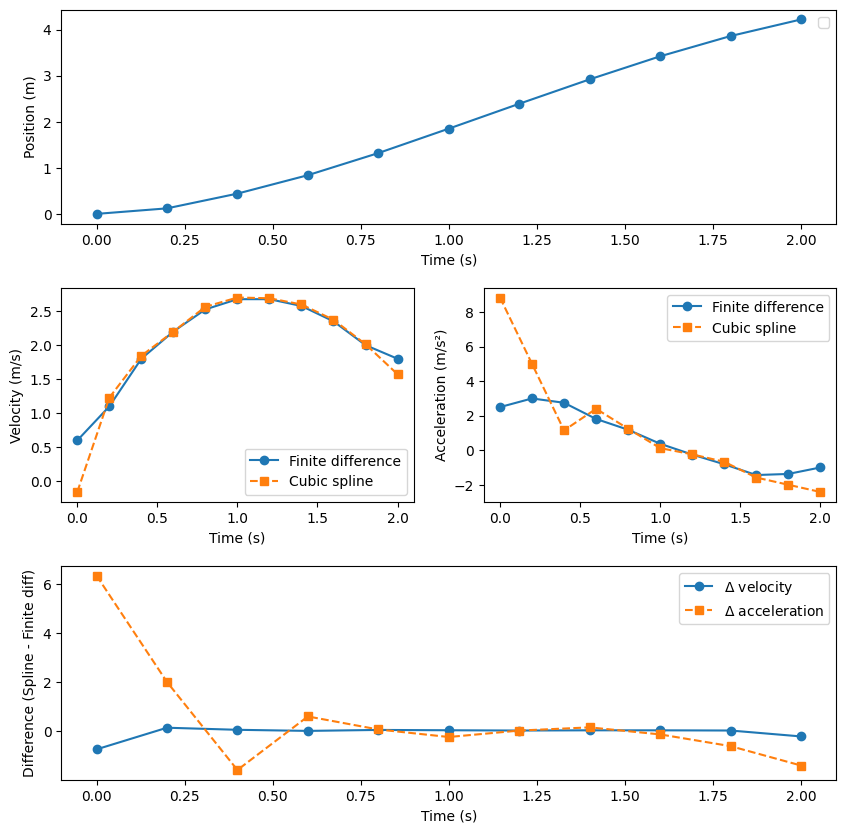

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import CubicSpline

"""
Compute and compare velocity and acceleration obtained using finite
differences and cubic spline interpolation, and display the results
in a four-panel figure.

Inputs:
    t: Time values.
    x: Position values corresponding to each time.

Output:
    A four-panel figure showing position, velocity, acceleration,
    and the differences between the spline and finite difference
    methods. The figure is saved as "EX_2.2.png".
"""

# Time and position data
t = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0])
x = np.array([0.0, 0.12, 0.44, 0.84, 1.32, 1.85, 2.39, 2.92, 3.42, 3.86, 4.22])

# Compute velocity and acceleration using finite differences
v_fd = np.gradient(x, t)
a_fd = np.gradient(v_fd, t)

# Create the cubic spline interpolation
cs = CubicSpline(t, x)

# Compute velocity and acceleration from the spline derivatives
v_spline = cs(t, 1)
a_spline = cs(t, 2)

# Compute the differences between both methods
diff_v = v_spline - v_fd
diff_a = a_spline - a_fd

# Create the figure
fig = plt.figure(figsize=(10, 10))

# Create a grid with 3 rows and 2 columns
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.3, wspace=0.2)

# Assign subplots to the grid
ax1 = fig.add_subplot(gs[0, :])    # Top panel spanning both columns
ax2 = fig.add_subplot(gs[1, 0])    # Middle-left panel
ax3 = fig.add_subplot(gs[1, 1])    # Middle-right panel
ax4 = fig.add_subplot(gs[2, :])    # Bottom panel spanning both columns

# Panel 1: Position
ax1.plot(t,
         x,
         marker='o',
         linestyle='-',
         color='tab:blue')

ax1.set_ylabel('Position (m)')
ax1.set_xlabel('Time (s)')

# Add the empty legend box shown in the original figure
ax1.legend([], loc='upper right')

# Panel 2: Velocity
ax2.plot(t,
         v_fd,
         marker='o',
         linestyle='-',
         label='Finite difference',
         color='tab:blue')

ax2.plot(t,
         v_spline,
         marker='s',
         linestyle='--',
         label='Cubic spline',
         color='tab:orange')

ax2.set_ylabel('Velocity (m/s)')
ax2.set_xlabel('Time (s)')
ax2.legend(loc='lower right')

# Panel 3: Acceleration
ax3.plot(t,
         a_fd,
         marker='o',
         linestyle='-',
         label='Finite difference',
         color='tab:blue')

ax3.plot(t,
         a_spline,
         marker='s',
         linestyle='--',
         label='Cubic spline',
         color='tab:orange')

ax3.set_ylabel('Acceleration (m/s²)')
ax3.set_xlabel('Time (s)')
ax3.legend(loc='upper right')

# Panel 4: Differences between both methods
ax4.plot(t,
         diff_v,
         marker='o',
         linestyle='-',
         label='$\Delta$ velocity',
         color='tab:blue')

ax4.plot(t,
         diff_a,
         marker='s',
         linestyle='--',
         label='$\Delta$ acceleration',
         color='tab:orange')

ax4.set_ylabel('Difference (Spline - Finite diff)')
ax4.set_xlabel('Time (s)')
ax4.legend(loc='upper right')

# Save the figure
plt.savefig('EX_2.2.png', dpi=300)

# Display the figure
plt.show()